### 1. Imports

In [31]:
from __future__ import annotations
import os
import random
from dataclasses import dataclass
from typing import Dict, Any, Optional
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import tensorflow as tf

# Sionna imports
try:
    import sionna
    from sionna.phy.mapping import Constellation, Mapper, Demapper
    from sionna.phy.fec.ldpc import LDPC5GEncoder, LDPC5GDecoder
    from sionna.phy.ofdm.demodulator import OFDMDemodulator
except Exception as e:
    raise ImportError("sionna must be installed and importable in this environment. Error: " + str(e))

### 2. Globals, hyperparameters, devices

In [32]:
DATA_PATH = "./data/radio_data.pth"   # <-- change if your saved dataset lives elsewhere

@dataclass(frozen=True)
class SimConfig:
    # Dataset size
    num_examples: int = 10_000

    # Modulation
    seq_length: int = 128
    bits_per_symbol: int = 4

    # LDPC (5G)
    k: int = 256

    # Pilots
    pilot_len: int = 16
    pilot_seed: int = 999

    # Channel: Eb/N0 range (info-bit)
    ebn0_db_min: float = 0.0
    ebn0_db_max: float = 10.0

    # Impairments ranges
    phase_min: float = -np.pi
    phase_max: float = np.pi

    # CFO configuration
    cfo_mode: str = "direct"
    cfo_norm_min: float = -0.002
    cfo_norm_max: float = 0.002
    cfo_eps_min: float = -0.05
    cfo_eps_max: float = +0.05

    # Receiver blocks
    demap_method: str = "app"
    dec_num_iter: int = 20
    cn_update: str = "minsum"

    # Reproducibility
    seed: int = 46
    seed_noise: Optional[int] = None
    llr_noise_scaling: float = 1.0

    # Waveform selection
    waveform: str = "ofdm"

    # Pilot constellation
    pilot_bits_per_symbol: int = 2

    # OFDM params
    ofdm_fft_size: int = 64
    ofdm_cp_len: int = 16
    ofdm_num_pilot_symbols: int = 1
    ofdm_num_data_symbols: int = 2
    ofdm_l_min: int = 0

    # Eb/N0 accounting flags
    include_pilot_overhead_in_no: bool = True
    include_cp_overhead_in_no: bool = True

    # Format / tf dtypes
    channels_last: bool = True
    tf_rdtype: tf.dtypes.DType = tf.float32
    tf_cdtype: tf.dtypes.DType = tf.complex64

### 3. Utils & Helpers

In [33]:
def set_seed_all(seed: int = 46):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(int(seed))
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    try:
        from sionna.phy import config as snc
        snc.seed = int(seed)
    except Exception:
        pass

def expj(theta: tf.Tensor, cdtype: tf.DType) -> tf.Tensor:
    return tf.cast(tf.complex(tf.math.cos(theta), tf.math.sin(theta)), cdtype)

def complex_from_chlast_np(iq: np.ndarray) -> tf.Tensor:
    """
    Convert numpy channels-last IQ [N, T, 2] -> tf.complex64 [N, T]
    """
    real = tf.convert_to_tensor(iq[..., 0].astype(np.float32))
    imag = tf.convert_to_tensor(iq[..., 1].astype(np.float32))
    return tf.cast(tf.complex(real, imag), tf.complex64)

### 4. Data Loading

In [34]:
def _torch_load_trusted(path: str):
    """
    Robust loader that attempts weights_only=False (PyTorch >=2.6) and
    if necessary allowlists numpy.core.multiarray._reconstruct for unpickling.
    Only use on trusted files.
    """
    if not os.path.exists(path):
        raise FileNotFoundError(path)

    last_exc = None
    try:
        # Preferred explicit call (PyTorch >= 2.6)
        return torch.load(path, map_location="cpu", weights_only=False)
    except TypeError:
        # older torch without weights_only keyword
        try:
            return torch.load(path, map_location="cpu")
        except Exception as e:
            last_exc = e
    except Exception as e:
        last_exc = e

    # Try allowlisting np.core.multiarray._reconstruct if present
    try:
        import torch.serialization as _ser
        try:
            # add_safe_globals exists in some torch versions
            _ser.add_safe_globals([np.core.multiarray._reconstruct])
        except Exception:
            # some torch versions expose safe_globals context manager
            try:
                _ser.safe_globals([np.core.multiarray._reconstruct])
            except Exception:
                pass
        # try again
        try:
            return torch.load(path, map_location="cpu", weights_only=False)
        except TypeError:
            return torch.load(path, map_location="cpu")
    except Exception:
        # re-raise original exception for debug
        raise last_exc if last_exc is not None else RuntimeError("torch.load failed for unknown reason")
    
# -------------------------
# Loader: reconstruct 'full' dict expected by the pipeline
# -------------------------
def load_saved_ofdm_full(data_path: str, key: str = "ofdm") -> Dict[str, Any]:
    saved = _torch_load_trusted(data_path)

    if not isinstance(saved, dict):
        raise TypeError(f"Loaded object is {type(saved)}; expected a dict saved by the generator notebook.")

    if key not in saved:
        raise KeyError(f"Key '{key}' not found. Available keys: {list(saved.keys())}")

    ds = saved[key]
    meta = ds.get("meta", {})

    # Expect channels-last IQ arrays saved as numpy floats: [N, T, 2]
    rx_iq = ds.get("rx_iq_full_time")
    if rx_iq is None:
        raise KeyError("Saved dataset missing 'rx_iq_full_time'.")

    y_rx = complex_from_chlast_np(rx_iq)  # tf.complex [N,T]

    tx_pilot_iq = ds.get("tx_iq_pilot_time")
    if tx_pilot_iq is None:
        raise KeyError("Saved dataset missing 'tx_iq_pilot_time'.")
    x_pilot = complex_from_chlast_np(tx_pilot_iq)  # [N,P_time]

    # Optional tx_grid saved as channels-last [N, n_total_sym, fft_size, 2]
    x_grid = None
    if "tx_grid" in ds and ds["tx_grid"] is not None:
        txg = ds["tx_grid"]
        real = tf.convert_to_tensor(txg[..., 0].astype(np.float32))
        imag = tf.convert_to_tensor(txg[..., 1].astype(np.float32))
        x_grid = tf.cast(tf.complex(real, imag), dtype=tf.complex64)

    # Bits / params - convert to TF arrays where needed
    info_bits_np = ds["info_bits"]
    coded_bits_np = ds["coded_bits"]
    pilot_bits_np = ds.get("pilot_bits", None)

    no_np = ds["no"]
    ebn0_db_np = ds["ebn0_db"]
    phi0_np = ds["phi0"]
    cfo_np = ds.get("cfo_norm", ds.get("cfo_eps", np.zeros_like(ebn0_db_np)))

    info_bits = tf.convert_to_tensor(info_bits_np.astype(np.uint8))
    coded_bits = tf.convert_to_tensor(coded_bits_np.astype(np.uint8))
    pilot_bits = tf.convert_to_tensor(pilot_bits_np.astype(np.uint8)) if pilot_bits_np is not None else None

    no = tf.convert_to_tensor(no_np.astype(np.float32))
    ebn0_db = tf.convert_to_tensor(ebn0_db_np.astype(np.float32))
    phi0 = tf.convert_to_tensor(phi0_np.astype(np.float32))
    cfo_norm = tf.convert_to_tensor(cfo_np.astype(np.float32))

    full = {
        "info_bits": info_bits,
        "coded_bits": coded_bits,
        "pilot_bits": pilot_bits,
        "x_pilot": x_pilot,
        "x_data": x_grid,
        "x_grid": x_grid,
        "x_tx": None,
        "y_rx": y_rx,
        "phi0": phi0,
        "cfo_norm": cfo_norm,
        "ebn0_db": ebn0_db,
        "no": no,
        "meta": meta,
    }
    return full

# -------------------------
# Sionna blocks builder
# -------------------------
def build_sionna_blocks(cfg: SimConfig):
    m = int(cfg.bits_per_symbol)
    constellation = Constellation("qam", num_bits_per_symbol=m)
    mapper = Mapper(constellation=constellation)
    demapper = Demapper(cfg.demap_method, constellation=constellation)

    n = int(cfg.seq_length) * m
    encoder = LDPC5GEncoder(k=int(cfg.k), n=int(n), num_bits_per_symbol=m)
    decoder = LDPC5GDecoder(
        encoder=encoder,
        num_iter=int(cfg.dec_num_iter),
        return_infobits=True,
        hard_out=True,
        cn_update=str(cfg.cn_update),
    )
    return constellation, mapper, demapper, encoder, decoder

# -------------------------
# CFO/phi estimator + classical receiver (identical logic to original)
# -------------------------
def estimate_phi_cfo_ml_grid(cfg: SimConfig,
                             y_pilot: tf.Tensor,
                             x_pilot: tf.Tensor,
                             cfo_min: float,
                             cfo_max: float,
                             grid_size: int = 129):
    rdtype = cfg.tf_rdtype
    cdtype = cfg.tf_cdtype

    P = tf.shape(y_pilot)[1]
    two_pi = tf.constant(2.0*np.pi, dtype=rdtype)
    eps_f = tf.constant(1e-9, dtype=rdtype)

    x_pow = tf.abs(x_pilot)**2
    r = y_pilot * tf.math.conj(x_pilot)
    r = r / tf.cast(x_pow + eps_f, cdtype)

    f_grid = tf.linspace(tf.constant(float(cfo_min), rdtype),
                         tf.constant(float(cfo_max), rdtype),
                         int(grid_size))

    p = tf.cast(tf.range(P)[None, :], rdtype)
    f = tf.reshape(f_grid, [-1, 1])
    theta = -two_pi * f * p

    E = tf.cast(tf.complex(tf.math.cos(theta), tf.math.sin(theta)), cdtype)

    z = tf.einsum("np,mp->nm", r, E)
    mags = tf.abs(z)
    idx = tf.argmax(mags, axis=1, output_type=tf.int32)

    cfo_hat = tf.gather(f_grid, idx)[:, None]
    z_best = tf.gather(z, idx, axis=1, batch_dims=1)
    z_best = z_best[:, None]

    phi_hat = tf.cast(tf.math.angle(z_best), rdtype)

    denom = tf.reduce_sum(tf.abs(r), axis=1, keepdims=True) + eps_f
    conf = tf.abs(z_best) / denom

    return phi_hat, cfo_hat, conf

def classical_receiver_with_phi_cfo(cfg: SimConfig,
                                    full: Dict[str, Any],
                                    phi_hat: tf.Tensor,
                                    cfo_hat: tf.Tensor) -> Dict[str, Any]:
    _, _, demapper, _, decoder = build_sionna_blocks(cfg)

    meta = full["meta"]
    waveform = meta.get("waveform", "sc")
    P = int(meta["P"])
    no = tf.cast(full["no"], cfg.tf_rdtype)

    y_rx = full["y_rx"]
    coded_bits = tf.cast(full["coded_bits"], tf.uint8)
    info_bits  = tf.cast(full["info_bits"],  tf.uint8)

    T = int(meta["T"])
    two_pi = tf.constant(2.0*np.pi, dtype=cfg.tf_rdtype)
    t = tf.cast(tf.range(T)[None, :], cfg.tf_rdtype)
    phi_total_hat = phi_hat + two_pi * cfo_hat * t
    y_corr = y_rx * expj(-phi_total_hat, cfg.tf_cdtype)

    if waveform == "sc":
        y_data_symbols = y_corr[:, P:]
    elif waveform == "ofdm":
        fft_size = int(meta["fft_size"])
        cp_len = int(meta["cp_len"])
        n_pilot_sym = int(meta["num_pilot_ofdm_symbols"])
        l_min = int(meta.get("ofdm_l_min", 0))

        demod = OFDMDemodulator(fft_size=fft_size, l_min=l_min, cyclic_prefix_length=cp_len)
        y_grid = demod(y_corr)
        y_data_grid = y_grid[:, n_pilot_sym:, :]
        y_data_symbols = tf.reshape(y_data_grid, [tf.shape(y_data_grid)[0], -1])
    else:
        raise ValueError(f"Unsupported waveform in meta: {waveform}")

    alpha = tf.constant(float(getattr(cfg, "llr_noise_scaling", 1.0)), dtype=cfg.tf_rdtype)
    no_eff = no * alpha

    llr = tf.cast(demapper(y_data_symbols, no_eff), cfg.tf_rdtype)
    hard_coded = tf.cast(llr > 0.0, tf.uint8)

    info_hat_f = decoder(llr)
    info_hat = tf.cast(info_hat_f > 0.5, tf.uint8)

    ber_pre = tf.reduce_mean(tf.cast(hard_coded != coded_bits, cfg.tf_rdtype))
    ber_post = tf.reduce_mean(tf.cast(info_hat != info_bits, cfg.tf_rdtype))
    bler_post = tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_bits, axis=1), cfg.tf_rdtype))

    return {
        "phi_hat": phi_hat,
        "cfo_hat": cfo_hat,
        "llr": llr,
        "info_bits_hat": info_hat,
        "metrics": {
            "ber_pre_coded": float(ber_pre.numpy()),
            "ber_post_info": float(ber_post.numpy()),
            "bler_post_info": float(bler_post.numpy()),
        }
    }

def classical_receiver(cfg: SimConfig, full: Dict[str, Any]) -> Dict[str, Any]:
    meta = full["meta"]
    waveform = meta.get("waveform", "sc")
    P = int(meta["P"])

    y_rx = full["y_rx"]
    x_pilot = full["x_pilot"]

    y_pilot = y_rx[:, :P]

    if waveform == "ofdm":
        fft_size = int(meta["fft_size"])
        if str(cfg.cfo_mode).lower() == "epsilon":
            cfo_min = float(cfg.cfo_eps_min) / float(fft_size)
            cfo_max = float(cfg.cfo_eps_max) / float(fft_size)
        else:
            cfo_min = float(cfg.cfo_norm_min)
            cfo_max = float(cfg.cfo_norm_max)
    else:
        cfo_min = float(cfg.cfo_norm_min)
        cfo_max = float(cfg.cfo_norm_max)

    if P >= 2:
        phi_hat, cfo_hat, conf = estimate_phi_cfo_ml_grid(
            cfg, y_pilot, x_pilot,
            cfo_min=cfo_min, cfo_max=cfo_max,
            grid_size=129
        )
    else:
        z = tf.reduce_sum(y_pilot * tf.math.conj(x_pilot), axis=1, keepdims=True)
        phi_hat = tf.cast(tf.math.angle(z), cfg.tf_rdtype)
        cfo_hat = tf.zeros_like(phi_hat)
        conf = tf.ones_like(phi_hat)

    out = classical_receiver_with_phi_cfo(cfg, full, phi_hat, cfo_hat)
    out["conf"] = conf
    return out

# -------------------------
# Extract OFDM data grid after receiver derotation
# -------------------------
def extract_ofdm_data_grid_after_rx_derotation(cfg: SimConfig, full: Dict[str, Any], rx: Dict[str, Any]) -> tf.Tensor:
    meta = full["meta"]
    fft_size = int(meta["fft_size"])
    cp_len = int(meta["cp_len"])
    n_pilot_sym = int(meta["num_pilot_ofdm_symbols"])
    n_data_sym = int(meta["num_data_ofdm_symbols"])
    T = int(meta["T"])

    y_rx = full["y_rx"]

    if ("phi_hat" in rx) and ("cfo_hat" in rx):
        phi_hat = rx["phi_hat"]
        cfo_hat = rx["cfo_hat"]
    else:
        phi_hat = tf.zeros([tf.shape(y_rx)[0], 1], dtype=cfg.tf_rdtype)
        cfo_hat = tf.zeros([tf.shape(y_rx)[0], 1], dtype=cfg.tf_rdtype)

    t = tf.cast(tf.range(T)[None, :], cfg.tf_rdtype)
    phi_total_hat = phi_hat + tf.constant(2.0*np.pi, dtype=cfg.tf_rdtype) * cfo_hat * t
    y_corr = y_rx * expj(-phi_total_hat, cfg.tf_cdtype)

    demod = OFDMDemodulator(fft_size=fft_size, l_min=int(meta.get("ofdm_l_min", 0)), cyclic_prefix_length=cp_len)
    y_grid = demod(y_corr)  # [N, n_total_sym, fft_size]
    y_data_grid = y_grid[:, n_pilot_sym:, :]
    y_data_grid = y_data_grid[:, :n_data_sym, :]
    return y_data_grid

# -------------------------
# Dataset builder from saved data (no simulation)
# -------------------------
def build_llr_refinement_dataset_ofdm_grid_from_saved(cfg: SimConfig, data_path: str, use_ebn0_feature: bool = True) -> Dict[str, Any]:
    full = load_saved_ofdm_full(data_path, key="ofdm")
    rx = classical_receiver(cfg, full)  # uses loaded frames to compute baseline llrs

    meta = full["meta"]
    if meta.get("waveform") != "ofdm":
        raise ValueError("Saved dataset waveform mismatch: expected 'ofdm'")

    fft_size = int(meta["fft_size"])
    n_data_sym = int(meta["num_data_ofdm_symbols"])
    m = int(meta.get("m", cfg.bits_per_symbol))
    N = int(meta["N"])

    y_data_grid = extract_ofdm_data_grid_after_rx_derotation(cfg, full, rx)  # [N,H,W] complex
    y_np = y_data_grid.numpy()

    llr_base_2d = rx["llr"].numpy().astype(np.float32)  # [N, n_bits]
    llr_base_hw_m = llr_base_2d.reshape(N, n_data_sym, fft_size, m)         # [N,H,W,m]
    llr_base = np.transpose(llr_base_hw_m, (0, 3, 1, 2)).astype(np.float32) # [N,m,H,W]

    coded_bits_np = full["coded_bits"].numpy().astype(np.uint8)
    y_bits_hw_m = coded_bits_np.reshape(N, n_data_sym, fft_size, m)
    y_bits = np.transpose(y_bits_hw_m, (0, 3, 1, 2)).astype(np.float32)

    I = np.real(y_np).astype(np.float32)
    Q = np.imag(y_np).astype(np.float32)
    A = np.abs(y_np).astype(np.float32)
    PH = (np.angle(y_np) / np.pi).astype(np.float32)

    feat_iq = np.stack([I, Q, A, PH], axis=1)        # [N,4,H,W]
    x_feat = np.concatenate([feat_iq, llr_base], axis=1).astype(np.float32) # [N,8,H,W]

    ebn0_db = full["ebn0_db"].numpy().astype(np.float32)
    if use_ebn0_feature:
        eb = (ebn0_db - cfg.ebn0_db_min) / max(1e-6, (cfg.ebn0_db_max - cfg.ebn0_db_min))
        eb = np.clip(eb, 0.0, 1.0).astype(np.float32)
        eb_map = eb[:, None, None, None] * np.ones((N, 1, n_data_sym, fft_size), dtype=np.float32)
        x_feat = np.concatenate([x_feat, eb_map], axis=1)  # [N,9,H,W]

    return {
        "x_feat": x_feat,
        "llr_base": llr_base,
        "y_bits": y_bits,
        "coded_bits": coded_bits_np,
        "info_bits": full["info_bits"].numpy().astype(np.uint8),
        "ebn0_db": ebn0_db,
        "meta": meta,
    }


### 5. Model definition and architecture

In [35]:
class ResBlock2D(nn.Module):
    def __init__(self, ch: int, k=(3, 5), drop: float = 0.0):
        super().__init__()
        pad = (k[0]//2, k[1]//2)
        self.c1 = nn.Conv2d(ch, ch, kernel_size=k, padding=pad)
        self.c2 = nn.Conv2d(ch, ch, kernel_size=k, padding=pad)
        self.b1 = nn.BatchNorm2d(ch)
        self.b2 = nn.BatchNorm2d(ch)
        self.drop = float(drop)
    def forward(self, x):
        h = F.gelu(self.b1(self.c1(x)))
        if self.drop > 0:
            h = F.dropout(h, p=self.drop, training=self.training)
        h = self.b2(self.c2(h))
        return F.gelu(x + h)

class LLRRefiner2D(nn.Module):
    def __init__(self, in_ch: int, hidden: int = 96, n_blocks: int = 6, delta_clip: float = 12.0, drop: float = 0.05):
        super().__init__()
        self.delta_clip = float(delta_clip)
        self.stem = nn.Conv2d(in_ch, hidden, kernel_size=1)
        self.blocks = nn.Sequential(*[ResBlock2D(hidden, k=(3,5), drop=drop) for _ in range(n_blocks)])
        self.head = nn.Conv2d(hidden, 4, kernel_size=1)
    def forward(self, x):
        h = F.gelu(self.stem(x))
        h = self.blocks(h)
        d = torch.tanh(self.head(h)) * self.delta_clip
        return d

### 6. Model training and validation

In [36]:
def llr_refinement_loss_grid(llr_refined: torch.Tensor,
                             y_bits: torch.Tensor,
                             ebn0_norm: torch.Tensor | None = None,
                             w_bce: float = 1.0,
                             w_bler: float = 0.3,
                             ebn0_focus_mid: float = 0.65,
                             ebn0_focus_sharp: float = 10.0):
    bce_el = F.binary_cross_entropy_with_logits(llr_refined, y_bits, reduction="none")  # [B,4,H,W]
    bce_b = bce_el.mean(dim=(1,2,3))  # [B]
    if ebn0_norm is not None:
        w = torch.sigmoid((ebn0_norm - ebn0_focus_mid) * ebn0_focus_sharp).detach()
        bce = (w * bce_b).mean()
    else:
        bce = bce_b.mean()
    sign = (y_bits * 2.0 - 1.0)
    p_err = torch.sigmoid(-sign * llr_refined)
    bler_proxy = p_err.amax(dim=(1,2,3)).mean()
    loss = w_bce*bce + w_bler*bler_proxy
    return loss, bce.detach(), bler_proxy.detach()

def llr_grid_to_2d(llr_grid: np.ndarray) -> np.ndarray:
    return np.transpose(llr_grid, (0, 2, 3, 1)).reshape(llr_grid.shape[0], -1)

def eval_metrics_with_ldpc(cfg: SimConfig, llr_2d: np.ndarray, coded_bits: np.ndarray, info_bits: np.ndarray):
    _, _, _, _, decoder = build_sionna_blocks(cfg)
    llr_tf = tf.convert_to_tensor(llr_2d.astype(np.float32))
    coded_tf = tf.convert_to_tensor(coded_bits.astype(np.uint8))
    info_tf = tf.convert_to_tensor(info_bits.astype(np.uint8))
    hard_coded = tf.cast(llr_tf > 0.0, tf.uint8)
    info_hat = tf.cast(decoder(llr_tf) > 0.5, tf.uint8)
    ber_pre = float(tf.reduce_mean(tf.cast(hard_coded != coded_tf, tf.float32)).numpy())
    ber_post = float(tf.reduce_mean(tf.cast(info_hat != info_tf, tf.float32)).numpy())
    bler_post = float(tf.reduce_mean(tf.cast(tf.reduce_any(info_hat != info_tf, axis=1), tf.float32)).numpy())
    return {"ber_pre_coded": ber_pre, "ber_post_info": ber_post, "bler_post_info": bler_post}

def train_llr_refiner_ofdm_conv2d_from_saved(cfg: SimConfig,
                                             data_path: str,
                                             epochs: int = 30,
                                             batch_size: int = 128,
                                             lr: float = 3e-4,
                                             seed: int = 46,
                                             use_ebn0_feature: bool = True,
                                             w_bce: float = 1.0,
                                             w_bler: float = 0.3,
                                             hidden: int = 96,
                                             n_blocks: int = 6,
                                             delta_clip: float = 12.0):
    set_seed_all(seed)
    torch.set_num_threads(4)
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    ds = build_llr_refinement_dataset_ofdm_grid_from_saved(cfg, data_path, use_ebn0_feature=use_ebn0_feature)

    x_feat = ds["x_feat"]          # [N,C,H,W]
    llr_base = ds["llr_base"]      # [N,4,H,W]
    y_bits = ds["y_bits"]          # [N,4,H,W]
    coded_bits = ds["coded_bits"]  # [N,n_bits]
    info_bits = ds["info_bits"]    # [N,k]
    ebn0_db = ds["ebn0_db"]        # [N]

    N = x_feat.shape[0]
    n_bits = coded_bits.shape[1]

    ebn0_norm = (ebn0_db - cfg.ebn0_db_min) / max(1e-6, (cfg.ebn0_db_max - cfg.ebn0_db_min))
    ebn0_norm = np.clip(ebn0_norm, 0.0, 1.0).astype(np.float32)

    # split 70/15/15
    n_tr = int(0.70 * N)
    n_va = int(0.15 * N)

    x_tr = torch.from_numpy(x_feat[:n_tr])
    lb_tr = torch.from_numpy(llr_base[:n_tr])
    y_tr = torch.from_numpy(y_bits[:n_tr])
    eb_tr = torch.from_numpy(ebn0_norm[:n_tr])

    x_va = torch.from_numpy(x_feat[n_tr:n_tr+n_va])
    lb_va = torch.from_numpy(llr_base[n_tr:n_tr+n_va])
    y_va = torch.from_numpy(y_bits[n_tr:n_tr+n_va])
    eb_va = torch.from_numpy(ebn0_norm[n_tr:n_tr+n_va])

    x_te = torch.from_numpy(x_feat[n_tr+n_va:])
    lb_te = llr_base[n_tr+n_va:]      # numpy [Nte,4,H,W]
    coded_te = coded_bits[n_tr+n_va:]
    info_te = info_bits[n_tr+n_va:]

    llr_base_te_2d = llr_grid_to_2d(lb_te)  # [Nte,n_bits] correct ordering

    tr_dl = DataLoader(TensorDataset(x_tr, lb_tr, y_tr, eb_tr), batch_size=batch_size, shuffle=True)
    va_dl = DataLoader(TensorDataset(x_va, lb_va, y_va, eb_va), batch_size=batch_size*2, shuffle=False)

    model = LLRRefiner2D(in_ch=x_feat.shape[1], hidden=hidden, n_blocks=n_blocks, delta_clip=delta_clip, drop=0.05).to(dev)
    n_params = sum(p.numel() for p in model.parameters())
    print(f"LLR refiner (Conv2D) parameters: {n_params}")

    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    sch = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    hist = {"tr_loss": [], "va_loss": [], "tr_bce": [], "va_bce": [], "tr_bp": [], "va_bp": []}
    best_val = 1e9
    best_state = None

    for ep in range(1, epochs+1):
        model.train()
        tr_loss = tr_bce = tr_bp = 0.0

        for xb, llrb, yb, ebb in tr_dl:
            xb = xb.to(dev)
            llrb = llrb.to(dev)
            yb = yb.to(dev)
            ebb = ebb.to(dev)

            delta = model(xb)             # [B,4,H,W]
            llr_ref = llrb + delta

            loss, bce_v, bp_v = llr_refinement_loss_grid(
                llr_ref, yb, ebn0_norm=ebb,
                w_bce=w_bce, w_bler=w_bler
            )

            opt.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
            opt.step()

            tr_loss += float(loss.item())
            tr_bce += float(bce_v.item())
            tr_bp += float(bp_v.item())

        model.eval()
        va_loss = va_bce = va_bp = 0.0
        with torch.no_grad():
            for xb, llrb, yb, ebb in va_dl:
                xb = xb.to(dev)
                llrb = llrb.to(dev)
                yb = yb.to(dev)
                ebb = ebb.to(dev)

                delta = model(xb)
                llr_ref = llrb + delta
                loss, bce_v, bp_v = llr_refinement_loss_grid(
                    llr_ref, yb, ebn0_norm=ebb,
                    w_bce=w_bce, w_bler=w_bler
                )

                va_loss += float(loss.item())
                va_bce += float(bce_v.item())
                va_bp += float(bp_v.item())

        sch.step()

        trn = max(1, len(tr_dl))
        van = max(1, len(va_dl))
        tr_loss /= trn; tr_bce /= trn; tr_bp /= trn
        va_loss /= van; va_bce /= van; va_bp /= van

        hist["tr_loss"].append(tr_loss); hist["va_loss"].append(va_loss)
        hist["tr_bce"].append(tr_bce);   hist["va_bce"].append(va_bce)
        hist["tr_bp"].append(tr_bp);     hist["va_bp"].append(va_bp)

        print(f"Epoch {ep:02d}/{epochs} | train_loss={tr_loss:.4f} (bce={tr_bce:.4f}, blerp={tr_bp:.4f}) | val_loss={va_loss:.4f} (bce={va_bce:.4f}, blerp={va_bp:.4f})")

        if va_loss < best_val:
            best_val = va_loss
            best_state = {k: v.detach().cpu() for k, v in model.state_dict().items()}

    if best_state is not None:
        model.load_state_dict(best_state)

    # ------------------ TEST ------------------
    model.eval()
    with torch.no_grad():
        delta_te = model(x_te.to(dev)).cpu().numpy()     # [Nte,4,H,W]

    llr_ref_te = lb_te + delta_te                        # [Nte,4,H,W]
    llr_ref_te_2d = llr_grid_to_2d(llr_ref_te)           # [Nte,n_bits]

    # sanity check
    print("sanity hard-acc baseline:", np.mean((llr_base_te_2d > 0).astype(np.uint8) == coded_te))
    print("sanity hard-acc refined :", np.mean((llr_ref_te_2d > 0).astype(np.uint8) == coded_te))

    baseline_metrics = eval_metrics_with_ldpc(cfg, llr_base_te_2d, coded_te, info_te)
    refined_metrics = eval_metrics_with_ldpc(cfg, llr_ref_te_2d, coded_te, info_te)

    print("\n================ TEST COMPARISON OFDM (Conv2D) ================")
    print("Baseline :", baseline_metrics)
    print("Refined  :", refined_metrics)
    bler_gain = (baseline_metrics["bler_post_info"] - refined_metrics["bler_post_info"]) / max(1e-12, baseline_metrics["bler_post_info"]) * 100.0
    print(f"BLER relative improvement: {bler_gain:.2f}%")

    return {
        "model": model,
        "history": hist,
        "baseline_metrics": baseline_metrics,
        "refined_metrics": refined_metrics,
        "n_params": n_params,
    }

### 7. Model evaluation and prints

In [37]:

@torch.no_grad()
def _predict_delta_in_batches(model, x_feat_np, batch_size=256, device=None):
    if device is None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    model.eval()

    N = x_feat_np.shape[0]
    out = np.zeros((N, 4, x_feat_np.shape[2], x_feat_np.shape[3]), dtype=np.float32)

    for i in range(0, N, batch_size):
        xb = torch.from_numpy(x_feat_np[i:i+batch_size]).to(device)
        delta = model(xb).cpu().numpy()
        out[i:i+batch_size] = delta
    return out

def eval_only_llr_refiner_ofdm_conv2d_from_saved(cfg: SimConfig, data_path: str, model: nn.Module, use_ebn0_feature: bool = True, seed: int = 46):
    set_seed_all(seed)
    dev = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(dev)
    model.eval()

    ds = build_llr_refinement_dataset_ofdm_grid_from_saved(cfg, data_path, use_ebn0_feature=use_ebn0_feature)

    x_feat = ds["x_feat"]
    llr_base = ds["llr_base"]
    coded_bits = ds["coded_bits"]
    info_bits = ds["info_bits"]

    N = x_feat.shape[0]
    n_bits = coded_bits.shape[1]

    # same split 70/15/15
    n_tr = int(0.70 * N)
    n_va = int(0.15 * N)

    x_te = torch.from_numpy(x_feat[n_tr+n_va:]).to(dev)
    lb_te = llr_base[n_tr+n_va:]
    coded_te = coded_bits[n_tr+n_va:]
    info_te = info_bits[n_tr+n_va:]

    llr_base_te_2d = llr_grid_to_2d(lb_te)

    with torch.no_grad():
        delta_te = model(x_te).cpu().numpy()

    llr_ref_te = lb_te + delta_te
    llr_ref_te_2d = llr_grid_to_2d(llr_ref_te)

    print("sanity hard-acc baseline:", np.mean((llr_base_te_2d > 0).astype(np.uint8) == coded_te))
    print("sanity hard-acc refined :", np.mean((llr_ref_te_2d > 0).astype(np.uint8) == coded_te))

    baseline_metrics = eval_metrics_with_ldpc(cfg, llr_base_te_2d, coded_te, info_te)
    refined_metrics = eval_metrics_with_ldpc(cfg, llr_ref_te_2d, coded_te, info_te)

    print("\n================ EVAL-ONLY OFDM (Conv2D) ================")
    print("Baseline :", baseline_metrics)
    print("Refined  :", refined_metrics)
    bler_gain = (baseline_metrics["bler_post_info"] - refined_metrics["bler_post_info"]) / max(1e-12, baseline_metrics["bler_post_info"]) * 100.0
    print(f"BLER relative improvement: {bler_gain:.2f}%")

    return {"baseline_metrics": baseline_metrics, "refined_metrics": refined_metrics}

def eval_curve_ebn0_ofdm_from_saved(cfg_base: SimConfig, model, data_path: str, ebn0_grid_db, n_per_point=5000, batch_size=256, use_ebn0_feature=True, seed=46):
    set_seed_all(seed)

    base_ber_pre, base_ber_post, base_bler = [], [], []
    ref_ber_pre,  ref_ber_post,  ref_bler  = [], [], []

    for idx, e in enumerate(ebn0_grid_db):
        cfg_e = SimConfig(**{ **cfg_base.__dict__, "ebn0_db_min": float(e), "ebn0_db_max": float(e) })
        ds = build_llr_refinement_dataset_ofdm_grid_from_saved(cfg_e, data_path, use_ebn0_feature=use_ebn0_feature)

        x_feat   = ds["x_feat"]
        llr_base = ds["llr_base"]
        coded    = ds["coded_bits"]
        info     = ds["info_bits"]

        # baseline metrics
        llr_base_2d = llr_grid_to_2d(llr_base)
        m_base = eval_metrics_with_ldpc(cfg_e, llr_base_2d, coded, info)

        # refined metrics
        delta = _predict_delta_in_batches(model, x_feat, batch_size=batch_size)
        llr_ref = llr_base + delta
        llr_ref_2d = llr_grid_to_2d(llr_ref)
        m_ref = eval_metrics_with_ldpc(cfg_e, llr_ref_2d, coded, info)

        base_ber_pre.append(m_base["ber_pre_coded"])
        base_ber_post.append(m_base["ber_post_info"])
        base_bler.append(m_base["bler_post_info"])

        ref_ber_pre.append(m_ref["ber_pre_coded"])
        ref_ber_post.append(m_ref["ber_post_info"])
        ref_bler.append(m_ref["bler_post_info"])

        print(f"Eb/N0={e:4.1f} dB | BASE postBER={m_base['ber_post_info']:.3e} BLER={m_base['bler_post_info']:.3e} | REF  postBER={m_ref['ber_post_info']:.3e} BLER={m_ref['bler_post_info']:.3e}")

    return {
        "ebn0_db": np.array(list(ebn0_grid_db), dtype=np.float32),

        "base_ber_pre": np.array(base_ber_pre, dtype=np.float32),
        "base_ber_post": np.array(base_ber_post, dtype=np.float32),
        "base_bler_post": np.array(base_bler, dtype=np.float32),

        "ref_ber_pre": np.array(ref_ber_pre, dtype=np.float32),
        "ref_ber_post": np.array(ref_ber_post, dtype=np.float32),
        "ref_bler_post": np.array(ref_bler, dtype=np.float32),
    }

def plot_curve(results, title_prefix="OFDM"):
    eb = results["ebn0_db"]

    plt.figure()
    plt.semilogy(eb, results["base_ber_post"], marker="o", label="Baseline post-BER")
    plt.semilogy(eb, results["ref_ber_post"], marker="o", label="Refiner post-BER")
    plt.grid(True, which="both")
    plt.xlabel("Eb/N0 [dB]")
    plt.ylabel("BER post-LDPC")
    plt.title(f"{title_prefix} | Post-BER vs Eb/N0")
    plt.legend()
    plt.show()

    plt.figure()
    plt.semilogy(eb, results["base_bler_post"], marker="o", label="Baseline BLER")
    plt.semilogy(eb, results["ref_bler_post"], marker="o", label="Refiner BLER")
    plt.grid(True, which="both")
    plt.xlabel("Eb/N0 [dB]")
    plt.ylabel("BLER post-LDPC")
    plt.title(f"{title_prefix} | BLER vs Eb/N0")
    plt.legend()
    plt.show()

### 8. Run

Starting LLR refiner training using saved dataset: ./data/radio_data.pth
LLR refiner (Conv2D) parameters: 1663684
Epoch 01/30 | train_loss=0.6318 (bce=0.3319, blerp=1.0000) | val_loss=0.4852 (bce=0.1852, blerp=0.9999)
Epoch 02/30 | train_loss=0.4510 (bce=0.1513, blerp=0.9992) | val_loss=0.4430 (bce=0.1434, blerp=0.9988)
Epoch 03/30 | train_loss=0.4080 (bce=0.1090, blerp=0.9968) | val_loss=0.4077 (bce=0.1093, blerp=0.9946)
Epoch 04/30 | train_loss=0.3925 (bce=0.0954, blerp=0.9903) | val_loss=0.4001 (bce=0.1042, blerp=0.9865)
Epoch 05/30 | train_loss=0.3850 (bce=0.0919, blerp=0.9769) | val_loss=0.3817 (bce=0.0919, blerp=0.9657)
Epoch 06/30 | train_loss=0.3742 (bce=0.0861, blerp=0.9601) | val_loss=0.3750 (bce=0.0910, blerp=0.9469)
Epoch 07/30 | train_loss=0.3695 (bce=0.0851, blerp=0.9481) | val_loss=0.3679 (bce=0.0891, blerp=0.9295)
Epoch 08/30 | train_loss=0.3606 (bce=0.0814, blerp=0.9307) | val_loss=0.3638 (bce=0.0882, blerp=0.9186)
Epoch 09/30 | train_loss=0.3573 (bce=0.0809, blerp=0.9

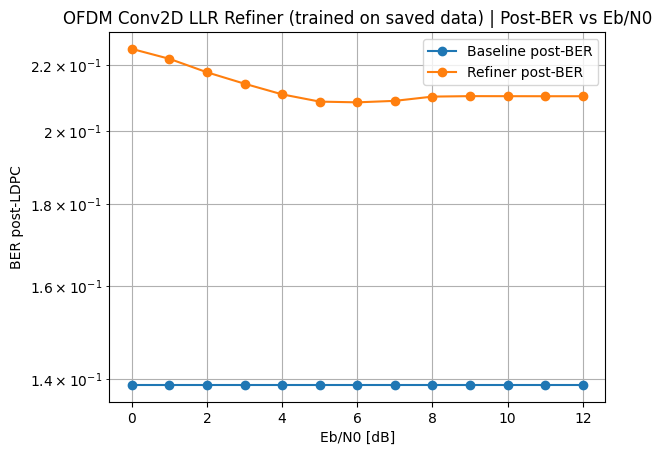

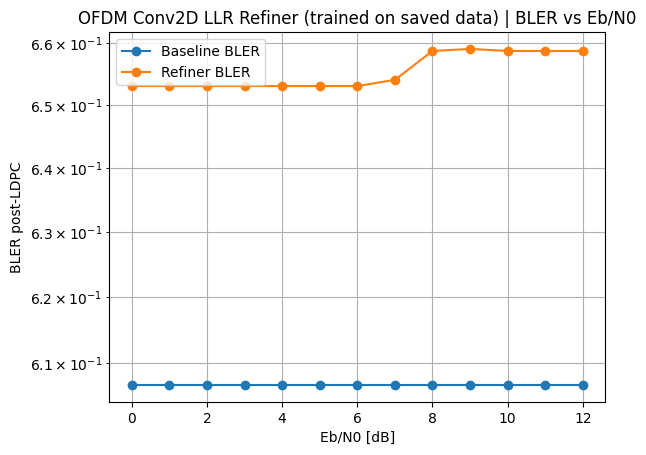

In [38]:
if __name__ == "__main__":
    print("Starting LLR refiner training using saved dataset:", DATA_PATH)

    cfg_ofdm_llr = SimConfig(**{
        "num_examples": 24000,
        "bits_per_symbol": 4,
        "k": 256,
        "demap_method": "app",
        "dec_num_iter": 15,
        "cn_update": "minsum",
        "seed": 46,
        "channels_last": True,
        "cfo_mode": "direct",
        "cfo_norm_min": -2e-4,
        "cfo_norm_max": +2e-4,
        "ebn0_db_min": 0.0,
        "ebn0_db_max": 12.0,
        "llr_noise_scaling": 1.0,
        "pilot_bits_per_symbol": 2,
        "include_pilot_overhead_in_no": True,
        "include_cp_overhead_in_no": True,
        "waveform": "ofdm",
        "seq_length": 128,
        "ofdm_fft_size": 64,
        "ofdm_cp_len": 16,
        "ofdm_num_pilot_symbols": 1,
        "ofdm_num_data_symbols": 2,
        "ofdm_l_min": 0,
    })

    # Train (this will load the saved dataset internally)
    ofdm_llr2d_results = train_llr_refiner_ofdm_conv2d_from_saved(
        cfg_ofdm_llr,
        data_path=DATA_PATH,
        epochs=30,
        batch_size=128,
        lr=3e-4,
        seed=46,
        use_ebn0_feature=True,
        hidden=96,
        n_blocks=6,
        delta_clip=12.0,
        w_bce=1.0,
        w_bler=0.3,
    )

    # Eval-only deterministic
    eval_only_results = eval_only_llr_refiner_ofdm_conv2d_from_saved(
        cfg_ofdm_llr, data_path=DATA_PATH, model=ofdm_llr2d_results["model"], use_ebn0_feature=True, seed=46
    )

    # Eb/N0 curve
    ebn0_grid_db = list(range(0, 13))  # 0..12
    results = eval_curve_ebn0_ofdm_from_saved(cfg_ofdm_llr, ofdm_llr2d_results["model"],
                                              data_path=DATA_PATH,
                                              ebn0_grid_db=ebn0_grid_db, n_per_point=4000, batch_size=256,
                                              use_ebn0_feature=True, seed=46)
    plot_curve(results, title_prefix="OFDM Conv2D LLR Refiner (trained on saved data)")